[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](
https://colab.research.google.com/github/Mariya-Skakalina/yandex-praktikum-analytics-2025-2026/blob/main/startup_research/startup_investigation_2015.ipynb)

# Проект. Исследование стартапов

**Автор**: Мария   
**Дата**: 02.08.2026

## Введение

Финансовая компания, работающая с венчурными инвестициями, хочет понять закономерности финансирования стартапов и оценить перспективы выхода на рынок с покупкой и развитием компаний. Для этого необходимо провести исследование на исторических данных. Вы поработаете с информацией о компаниях, объёмах и типах 

**Цель проекта** - исследовать динамику и структуру финансирования стартапов и ответить на вопросы, важные для оценки инвестиционных стратегий.

**Задачи:**
- провести предобработку данных, убрать дубликаты и пропуски, проверить корректность числовых и временных значений.   
- выделить группы компаний по срокам финансирования и сравнить их по количеству и объёму инвестиций.   
- классифицировать сегменты рынка на массовые, средние и нишевые и учесть это в дальнейшем анализе.
- определить типичные и аномальные значения объёмов финансирования, исключить выбросы и ограничить период исследования.   
- сравнить популярность и объёмы разных типов финансирования.
- проанализировать динамику раундов и объёмов инвестиций по годам, а также изменения в массовых сегментах рынка.
- рассчитать долю возврата средств для разных типов финансирования и оценить её устойчивость.
- подвести итоговые выводы и дать рекомендации, куда и каким образом было бы целесообразно инвестировать, если бы на дворе был 2015 год.

**Содержание проекта:**   
[1. Шаг 1. Знакомство с данными: загрузка и предобработка](#step1)  
[2. Шаг 2. Инжиниринг признаков](#step2)  
[3. Шаг 3. Работа с выбросами и анализ](#step3)  
[4. Шаг 4. Анализ динамики](#step4)  
[5. Шаг 5. Итоговый вывод и рекомендации](#step5)  

<a id="step1"></a>
## Шаг 1. Знакомство с данными: загрузка и предобработка

Датасет получен из базы данных стартапов.

Название основного датасета — `cb_investments.zip`. Внутри архива один файл — `cb_investments.csv`.

Описание данных:
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных:
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.

Файлы находятся в папке `datasets`, если вы выполняете работу на платформе. В случае, если вы делаете работу локально, доступ к файлам в папке можно получить по адресу `https://code.s3.yandex.net/datasets/` + имя файла.

<a id='step11'></a>
### 1.1. Вывод общей информации


Загрузите необходимые для работы библиотеки.

Совет: если вы неоднократно используете какой-либо код, вынесите его в начало проекта в виде функций.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

In [67]:
funding_cols = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
    'convertible_note', 'debt_financing', 'angel', 'grant',
    'private_equity', 'post_ipo_equity', 'post_ipo_debt',
    'secondary_market', 'product_crowdfunding'
]

In [2]:
pd.set_option('display.max_columns', None) # показывать все колонки 
pd.set_option('display.width', 0)

Загрузите все данные по проекту.

Совет: данные из zip-архива можно загрузить следующим кодом:

`df = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)`

In [3]:
df = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)
df_returns = pd.read_csv("https://code.s3.yandex.net/datasets/cb_returns.csv")

In [4]:
df_original = df.copy()  # Создаем копию оригинального датафрейма для резервного хранения данных    
df_returns_original = df_returns.copy()  # Копия для df_returns

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

In [6]:
df.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,1.0,NaN,1636-09-08,NaN,NaN,1636.0,2014-01-06,NaN,2014-01-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,90000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,1.0,NaN,1785-01-01,NaN,NaN,1785.0,2014-05-15,NaN,2014-05-15,0.0,2000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,1.0,1.0,1802-07-19,NaN,NaN,1802.0,2009-07-02,2009-07-02,2009-07-02,0.0,9000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,3.0,0.0,1817-01-01,NaN,NaN,1817.0,2013-11-21,2013-11-21,2014-11-03,0.0,0.0,0.0,1600000.0,0.0,0.0,0.0,6100000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,1.0,NaN,1826-01-01,NaN,NaN,1826.0,2014-01-14,NaN,2014-01-14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,540000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
df.funding_rounds.unique()

array([ 1.,  3.,  4.,  2.,  5.,  9.,  7.,  6., 11., 10.,  8., 15., 12.,
       13., 14., 18., 16., nan])

In [8]:
df.status.unique()

array(['operating', 'acquired', nan, 'closed'], dtype=object)

In [9]:
df.participants.unique()

array([nan,  1.,  0.,  2., 10.,  3.,  5.,  7.,  4.,  8.,  6.,  9., 12.,
       13., 14., 18., 11., 15., 23., 17., 21., 26., 16., 19., 22., 27.,
       28., 20., 25., 36., 24., 32., 29.])

Датасет `cb_investments` содержит 54 294 строк и 40 столбцов.  
Общая информация по данным позволяет выделить несколько ключевых аспектов, требующих предобработки.

**Типы данных:**
- Столбец `funding_total_usd` имеет тип `object`, хотя должен быть числовым. Удаление всех запятых даёт корректное числовое значение, однако этот факт необходимо зафиксировать как особенность источника.
- Числовые столбцы `funding_rounds` и `participants` представлены как `float64`, несмотря на то, что содержат целочисленные значения. После проверки диапазона их можно оптимизировать до `Int16` или `Int32`.
- Временные поля - `first_funding_at`, `mid_funding_at`, `last_funding_at` — имеют тип `object`. Требуется преобразование в `datetime64[ns]`. 
- Категориальные признаки, такие как `status`, `country_code`, `market`, могут быть переведены в тип `category` для экономии памяти и ускорения операций группировки.

**Проблемы с качеством данных:**
- В названиях некоторых столбцов (` market`, ` funding_total_usd`) присутствуют начальные пробелы. Это затрудняет программный доступ к данным. Рекомендуется выполнить `.str.strip()` для всех имён столбцов.
- Пропуски наблюдаются почти во всех столбцах:
  - `name` — 4 857 пропущенных значений;
  - `country_code`, `region` — около 10 000;
  - `mid_funding_at` — более 23 000.
- Особенно критичны пропуски в `funding_total_usd` (почти 5 000), но большинство из них могут быть восстановлены через суммирование значений по типам финансирования.

**Вывод:**  
Перед началом анализа необходимо:
1. Привести названия столбцов к единому формату.
2. Преобразовать `funding_total_usd` в числовой тип.
3. Проверить и преобразовать временные столбцы.
4. Оценить необходимость удаления или восстановления пропущенных значений в ключевых полях.

In [10]:
df_returns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


In [11]:
df_returns.head()

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
1,2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2,2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
3,2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
4,2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


In [12]:
df_returns.year.unique()

array([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010,
       2011, 2012, 2013, 2014])

Датасет `cb_returns` содержит **15** строк и **14** столбцов. Данные агрегированы по годам: каждая строка соответствует одному году, а столбцы — суммам возвратов средств по типам финансирования (в миллионах долларов).   

Ключевые наблюдения:
- Пропусков нет: все значения заполнены.
- Столбец `year` логически является идентификатором временного периода и может быть установлен как индекс.
- Все числовые столбцы имеют тип `float64`, что избыточно для данного масштаба данных. Рекомендуется преобразовать их в `float32` для экономии памяти.
- Тип `int64` для `year` также избыточен — достаточно `int16`.
- Наименование столбцов в нужном типе и не содержит пропусков

**Вывод**:   
Датасет технически чист, но требует оптимизации типов и семантической настройки индекса перед использованием в расчётах.


### 1.2. Предобработка данных

Проверьте названия столбцов в датасетах: все ли они точно отражают содержимое данных и оформлены в удобном для работы стиле. При необходимости приведите их к единому аккуратному стилю.

In [13]:
df.columns = df.columns.str.strip()
df.columns

Index(['name', 'homepage_url', 'category_list', 'market', 'funding_total_usd',
       'status', 'country_code', 'state_code', 'region', 'city',
       'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_A', 'round_B',
       'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H'],
      dtype='object')

Уберите в столбце `funding_total_usd` выделение разрядов и приведите его к числовому типу.

In [14]:
df['funding_total_usd'] = df['funding_total_usd'].str.replace(',', '', regex=False)
df['funding_total_usd'] = pd.to_numeric(df['funding_total_usd'], errors='coerce')
print(df['funding_total_usd'].dtype)  
print(df['funding_total_usd'].isna().sum())  

float64
13387


Обработайте типы данных в столбцах, которые хранят значения даты и времени, если это необходимо.

In [15]:
for i in ['mid_funding_at', 'first_funding_at', 'last_funding_at']:
    df[i] = pd.to_datetime(df[i], errors='coerce')
df[['first_funding_at', 'last_funding_at', 'mid_funding_at']].dtypes

first_funding_at    datetime64[ns]
last_funding_at     datetime64[ns]
mid_funding_at      datetime64[ns]
dtype: object

В датасете `cb_returns` сделайте столбец `year` индексом всего датасета, если не делали это при загрузке.

In [16]:
df_returns.set_index('year', inplace=True)
print(df_returns.index.dtype)

int64


In [17]:
print(df_returns.index.is_monotonic_increasing)

True


Обработайте текстовые данные, если это необходимо. Пропуски в текстовых столбцах заполните заглушками там, где это понадобится.

In [18]:
df['market'] = df['market'].fillna('unknown')
df['country_code'] = df['country_code'].fillna('unknown')
df['category_list'] = df['category_list'].fillna('unknown')
df[['market', 'country_code', 'category_list']].isna().sum()

market           0
country_code     0
category_list    0
dtype: int64

In [19]:
df.market = df.market.str.lower().str.strip()
df.market.nunique()

440

Обработайте полные дубликаты в данных и пропуски в `funding_total_usd`. избавьтесь от тех строк, которые не несут какой-либо информации либо не содержат данных о финансировании.

In [20]:
df = df.drop_duplicates()
df.duplicated().sum()


np.int64(0)

In [ ]:
df['total_from_types'] = df[funding_cols].sum(axis=1)
df['funding_total_usd'] = df['funding_total_usd'].fillna(df['total_from_types'])
df = df[(df['funding_total_usd'] > 0) | (df['total_from_types'] > 0)].copy()
df.head(3)

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H,total_from_types
0,Harvard University,http://harvard.edu,|Education|,education,90000000.0,operating,USA,MA,Boston,Cambridge,1.0,NaN,1636-09-08,NaN,NaN,1636.0,2014-01-06,NaT,2014-01-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,90000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,90000000.0
1,University of New Brunswick,http://www.unb.ca,unknown,unknown,2000000.0,operating,unknown,NaN,NaN,NaN,1.0,NaN,1785-01-01,NaN,NaN,1785.0,2014-05-15,NaT,2014-05-15,0.0,2000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2000000.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,business services,9000000.0,operating,USA,DE,"Wilmington, Delaware",Wilmington,1.0,1.0,1802-07-19,NaN,NaN,1802.0,2009-07-02,2009-07-02,2009-07-02,0.0,9000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9000000.0


Заполните пропуски в значениях `mid_funding_at` на основании значений в столбцах `first_funding_at` и `last_funding_at`. В качестве нового значения вместо пропусков возьмите приблизительно середину интервала между этими двумя датами.

Оцените размер оставшихся пропусков в столбце.

In [22]:
mask_can_calculate = (
    df['mid_funding_at'].isna() &
    df['first_funding_at'].notna() &
    df['last_funding_at'].notna()
)
df.loc[mask_can_calculate, 'mid_funding_at'] = (
    df['first_funding_at'] + (df['last_funding_at'] - df['first_funding_at']) / 2
)
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if missing.empty:
    print("Пропусков в данных нет — всё чисто!")
else:
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': missing,
        'Процент пропусков': (missing / len(df)).round(4)
    })
    display(missing_stats.style
            .background_gradient(cmap='coolwarm')
            .format({'Процент пропусков': '{:.2%}'}))

,Кол-во пропусков,Процент пропусков
state_code,15288,37.37%
participants,13576,33.19%
founded_month,8772,21.44%
founded_quarter,8772,21.44%
founded_at,8706,21.28%
founded_year,8706,21.28%
city,4505,11.01%
region,3819,9.34%
homepage_url,2314,5.66%
status,1105,2.70%


In [23]:
df = df[df['first_funding_at'].notna()].copy()
df.first_funding_at.isna().sum()

np.int64(0)

Оцените полноту данных и сделайте предварительный вывод о том, достаточно ли данных для решения задач проекта. Какой процент данных был отброшен?

In [24]:
dr_dup = df_original.shape[0]-df.shape[0]
dr_dup

13389

In [25]:
dr_dup/df_original.shape[0]

0.24660183445684605

После удаления записей, не содержащих информации о финансировании, объём датасета сократился с **54 294** до **40 905** строк — это **24.7%** потерь.  
Удалённые строки соответствуют компаниям без указания суммы финансирования, количества раундов или значений по типам вложений.  

Оставшийся датасет является репрезентативным: он содержит достаточное количество наблюдений для анализа структуры и динамики инвестиций.  
Фильтрация повысила качество данных, исключив шум и артефакты.

<a id="step2"></a>
## Шаг 2. Инжиниринг признаков

При выполнении заданий не забывайте интерпретировать полученные результаты и делать промежуточные выводы.

### 2.1. Группы по срокам финансирования

Разделите все компании на три группы:

* Единичное финансирование — был всего один раунд финансирования.

* Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.

* Срок финансирования более года.

Визуализируйте соотношение этих групп, создав два графика:

* По количеству компаний: Покажите, какой процент от общего числа компаний относится к каждой из трёх групп.
* По объёму инвестиций: Отобразите, какую долю от общего объёма привлечённых средств получила каждая группа.

Совет: Для ясности и согласованности используйте единую цветовую палитру для всех графиков, чтобы каждая категория (например, «Единичное финансирование») всегда отображалась одним цветом.

In [26]:
funding_duration = df['last_funding_at'] - df['first_funding_at']
funding_duration_days = funding_duration.dt.days  # Извлекаем число дней

In [27]:
conditions = [
    df['funding_rounds'] == 1,
    (df['funding_rounds'] > 1) & (funding_duration_days <= 365),
    (df['funding_rounds'] > 1) & (funding_duration_days > 365)
]

choices = ['Единичное финансирование', 'Срок финансирования до года', 'Срок финансирования более года']

df['finance_group'] = np.select(conditions, choices, default='Неопределено')
df['finance_group'].value_counts()

finance_group
Единичное финансирование          24113
Срок финансирования более года    12291
Срок финансирования до года        4501
Name: count, dtype: int64

In [28]:
palette = {
    'Единичное финансирование': '#4c72b0',        
    'Срок финансирования до года': '#55a868',     
    'Срок финансирования более года': '#c44e52'
}

In [29]:
group_company = (
    df['finance_group']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

group_company.columns = ['finance_group', 'percentage']
group_company = group_company.sort_values('percentage', ascending=False)

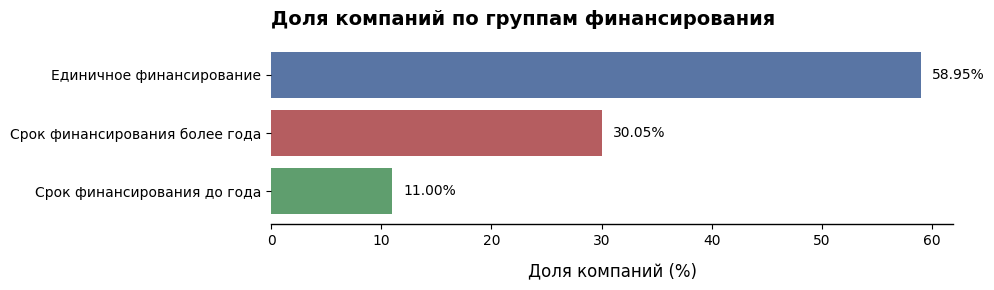

In [30]:

plt.figure(figsize=(10, 3))
ax = sns.barplot(
    data=group_company,
    y='finance_group',
    x='percentage',
    hue='finance_group',
    palette=palette,
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=8, fontsize=10, color='black')

sns.despine(left=True, top=True)
plt.title('Доля компаний по группам финансирования', fontsize=14, pad=15, loc='left', fontweight='semibold')
plt.xlabel('Доля компаний (%)', fontsize=12, labelpad=10)
plt.ylabel('')
ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)
ax.spines['bottom'].set_position(('outward', 3))
plt.grid(False)
plt.tight_layout()
plt.show()

In [31]:
group_funding = (
    df.groupby('finance_group')['funding_total_usd']
    .sum()
    .reset_index()
)

total_investment = group_funding['funding_total_usd'].sum()
group_funding['share'] = (group_funding['funding_total_usd'] / total_investment * 100).round(2)

group_funding = group_funding.sort_values('share', ascending=False).reset_index(drop=True)

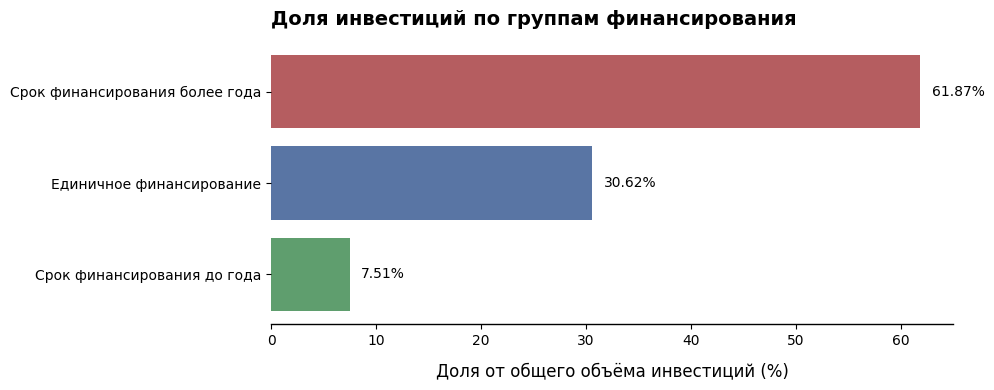

In [32]:
plt.figure(figsize=(10, 4))

ax = sns.barplot(
    data=group_funding,
    y='finance_group',
    x='share',
    hue='finance_group',
    palette=palette,
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=8, fontsize=10, color='black')


sns.despine(left=True, top=True)
plt.title('Доля инвестиций по группам финансирования', fontsize=14, pad=15, loc='left', fontweight='semibold')
plt.xlabel('Доля от общего объёма инвестиций (%)', fontsize=12, labelpad=10)
plt.ylabel('')
ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)
ax.spines['bottom'].set_position(('outward', 3))
plt.grid(False)
plt.tight_layout()
plt.show()

### Промежуточный вывод по группам финансирования

**По количеству компаний:**
- Подавляющее большинство (**58.95%**) получили **единичное финансирование**.
- **30.05%** прошли более одного раунда с интервалом **свыше года**.
- Только *11%* компаний прошли несколько раундов в **пределах года**.
> Это говорит о том, что рынок состоит преимущественно из проектов, получивших одноразовое вливание.

**По объёму инвестиций:**   
- Наибольшую долю средств (**61.87%**) привлекли компании с длительным циклом финансирования (>1 года).
- Проекты с единичным раундом собрали **30.62%** — значительно меньше, несмотря на их численное превосходство.
- Компании с короткими сроками (<1 года) заняли минимальную долю — около **7.5%**.

**Компании, которые привлекают финансирование менее года, но более одного раза, демонстрируют осторожную стратегию:**
- они не получают крупных сумм,
- не привлекают капитал часто,
- и, вероятно, находятся на ранних стадиях развития или в условиях неопределённости, что снижает готовность инвесторов вкладывать значительные средства.

**В противоположность этому, компании с длительным циклом финансирования оказываются наиболее привлекательными для инвесторов и аккумулируют большую часть инвестиций.**

### 2.2 Выделение средних и нишевых сегментов рынка

Компании указывают свой сегмент рынка в столбце `market`. Рассчитайте, как часто в датасете встречается каждый из сегментов. Сегменты, к которым относится более 120 компаний, отнесите к массовым, сегменты, в которые входит от 35 до 120 включительно, отнесите к средним, а сегменты до 35 компаний отнесите к нишевым. Рассчитайте, сколько сегментов попадает в каждую из категорий.

Постройте график распределения количества компаний в сегментах и отобразите на нём разделение на нишевые и средние сегменты.

Оставьте в столбце `market` только массовые сегменты. Для остальных сегментов замените значения на заглушки — `niche` для нишевых и `mid` для средних.

Дальнейшие исследования выполняйте с учётом этой замены. Индивидуальные сегменты внутри средней и нишевой групп рассматривать не нужно — они объединяются в два общих сегмента.


In [33]:
market_counts = df['market'].value_counts().reset_index()
market_counts.columns = ['market', 'count']

In [34]:
conditions = [
    market_counts['count'] > 120,
    market_counts['count'].between(35, 120),
    market_counts['count'] < 35
]

choices = ['Массовый', 'Средний', 'Нишевый']

market_counts['category'] = np.select(conditions, choices, default='unknown')
market_group = market_counts['category'].value_counts().reset_index()
market_group.columns = ['market_category', 'number_of_markets']
market_group

,market_category,number_of_markets
0,Нишевый,289
1,Средний,57
2,Массовый,49


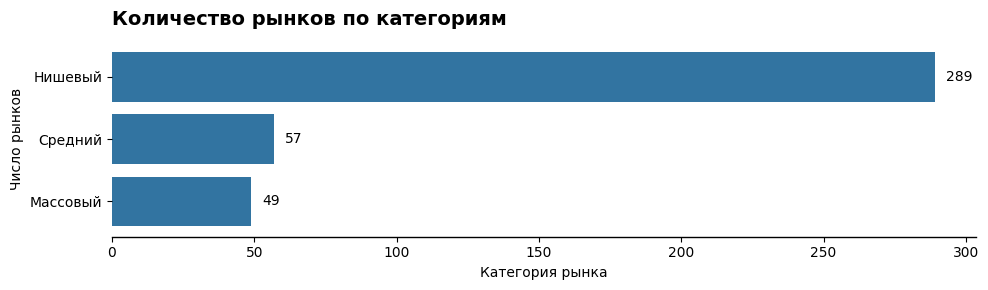

In [35]:
plt.figure(figsize=(10, 3))
ax = sns.barplot(
    data=market_group,
    y='market_category',
    x='number_of_markets'
)

for container in ax.containers:
    ax.bar_label(container, padding=8, fontsize=10, color='black')

sns.despine(left=True, top=True)
plt.title('Количество рынков по категориям', fontsize=14, pad=15, loc='left', fontweight='semibold')
plt.xlabel('Категория рынка')
plt.ylabel('Число рынков')
ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1)
ax.spines['bottom'].set_position(('outward', 3))
plt.grid(False)
plt.tight_layout()
plt.show()

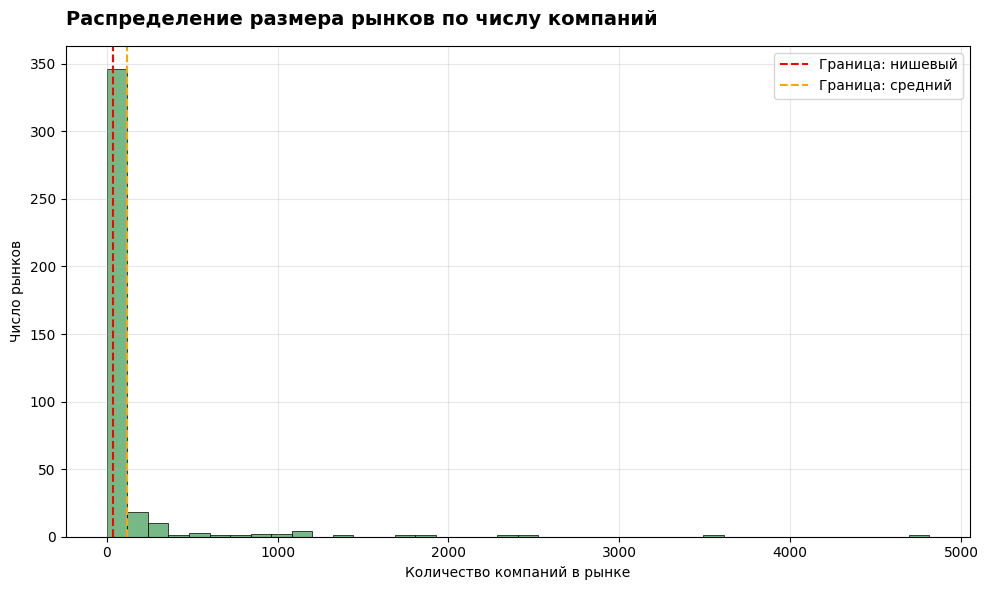

In [36]:
plt.figure(figsize=(10, 6))
sns.histplot(market_counts['count'], bins=40, color='#55a868', alpha=0.8, edgecolor='black', linewidth=0.5)
plt.axvline(x=35, color='red', linestyle='--', label='Граница: нишевый')
plt.axvline(x=121, color='orange', linestyle='--', label='Граница: средний')
plt.title('Распределение размера рынков по числу компаний', fontsize=14, pad=15, loc='left', fontweight='semibold')
plt.xlabel('Количество компаний в рынке')
plt.ylabel('Число рынков')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [37]:
market_to_grouped = {}

for _, row in market_counts.iterrows():
    mkt = row['market']
    cnt = row['count']
    
    if cnt > 120:
        market_to_grouped[mkt] = mkt  
    elif cnt >= 35: 
        market_to_grouped[mkt] = 'mid'
    else:  # <35
        market_to_grouped[mkt] = 'niche'

df['market'] = df['market'].map(market_to_grouped)

In [38]:
df['market'].nunique()

51

### Частота сегментов рынка и их классификация

Сегменты были разделены на три группы по количеству компаний:

- **Массовые сегменты** — более 120 компаний  
- **Средние сегменты** — от 35 до 120 компаний  
- **Нишевые сегменты** — менее 35 компаний  

По результатам анализа:

- Массовых сегментов: **49**
- Средних сегментов: **57**
- Нишевых сегментов: **289**

График распределения показывает, что большинство сегментов относятся к нишевым, а массовых сегментов относительно немного. Линии на графике отмечают границы между нишевыми и средними сегментами.


## Шаг 3. Работа с выбросами и анализ

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов

Заказчика интересует обычный для рассматриваемого периода размер средств, который предоставлялся компаниям.

По предобработанному столбцу `funding_total_usd` графическим образом оцените, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся. Укажите интервал, в котором лежат типичные значения.

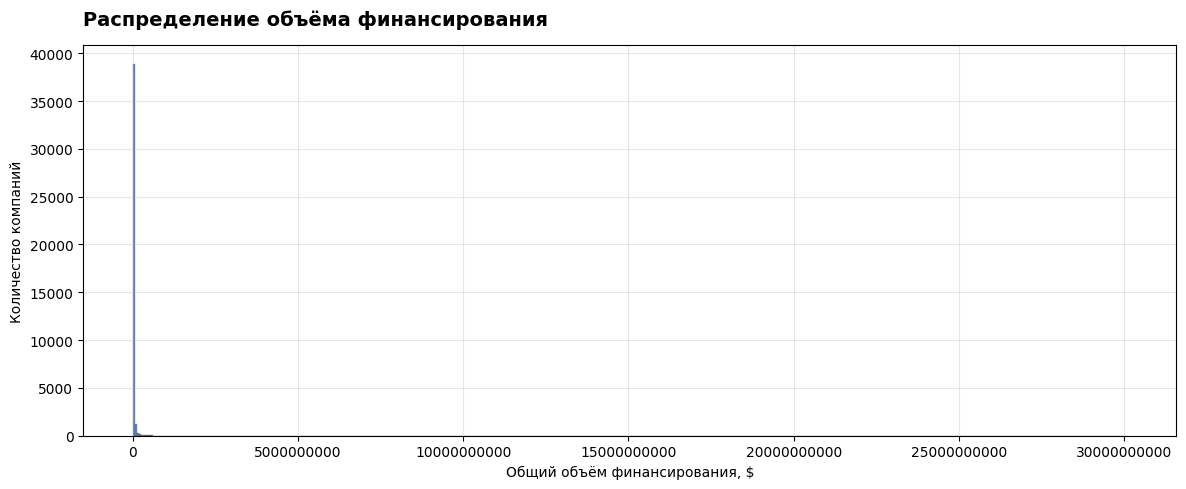

In [39]:
plt.figure(figsize=(12, 5))

ax = sns.histplot(
    df['funding_total_usd'],
    bins=500,
    color='#4c72b0',
    alpha=0.8
)
ax.ticklabel_format(style='plain', axis='x')
ax.get_xaxis().get_major_formatter().set_useOffset(False)

plt.title(
    'Распределение объёма финансирования',
    fontsize=14,
    pad=15,
    loc='left',
    fontweight='semibold'
)

plt.xlabel('Общий объём финансирования, $')
plt.ylabel('Количество компаний')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


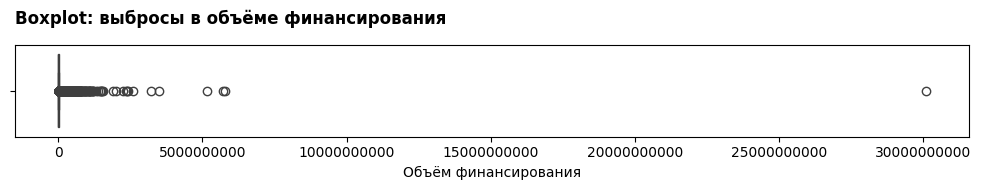

In [40]:
plt.figure(figsize=(10, 2))
ax = sns.boxplot(data=df, x='funding_total_usd')
plt.title('Boxplot: выбросы в объёме финансирования', loc='left', fontweight='semibold', pad=15)
plt.xlabel('Объём финансирования')
plt.grid(False)
ax.ticklabel_format(style='plain', axis='x')
ax.get_xaxis().get_major_formatter().set_useOffset(False)
plt.tight_layout()
plt.show()

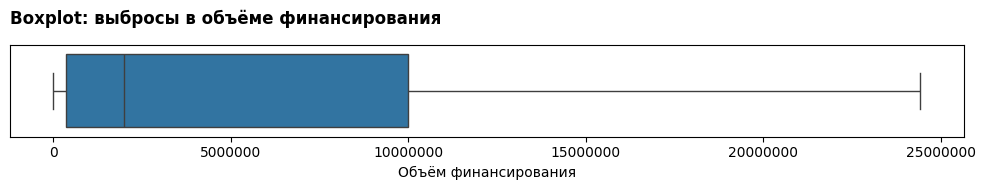

In [41]:
plt.figure(figsize=(10, 2))

ax = sns.boxplot(
    data=df,
    x='funding_total_usd',
    showfliers=False
)
plt.title('Boxplot: выбросы в объёме финансирования', loc='left', fontweight='semibold', pad=15)
plt.xlabel('Объём финансирования')

# отключаем научную нотацию
ax.ticklabel_format(style='plain', axis='x')
ax.get_xaxis().get_major_formatter().set_useOffset(False)
plt.yticks([])
plt.tight_layout()
plt.show()


In [42]:
pd.set_option('display.float_format', '{:,.0f}'.format) 
df['funding_total_usd'].describe()

count           40,905
mean        15,912,466
std        168,682,924
min                  1
25%            350,000
50%          2,000,000
75%         10,000,000
max     30,079,503,000
Name: funding_total_usd, dtype: float64

Распределение объёма финансирования имеет ярко выраженную правостороннюю асимметрию. Большинство компаний привлекают относительно небольшие суммы (медиана — 2 млн долларов, 75‑й перцентиль — 10 млн), однако в данных присутствует значительное количество крупных выбросов. Максимальные значения превышают медиану более чем в 10 000 раз, что приводит к сильному смещению среднего значения и делает его нерепрезентативным. Для анализа предпочтительно использовать медиану, квартильные показатели и визуализации без выбросов или с логарифмической шкалой.

Определите компании с аномальным объёмом общего финансирования — используйте метод IQR отдельно по каждому сегменту. Напомним, что все нишевые сегменты должны быть объединены в одну группу, а средние — в другую.

Определите сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование, и выведите топ таких сегментов.

In [43]:
def mark_outliers_series(s):
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return (s < lower) | (s > upper)

df['is_outlier'] = (
    df.groupby('market')['funding_total_usd']
      .apply(mark_outliers_series)
      .reset_index(level=0, drop=True)
)

In [44]:
top_outliers = (
    df.groupby('market')['is_outlier']
    .mean()
    .sort_values(ascending=False)
    .head()
)

top_outliers.map(lambda x: f"{x:.4f}")

market
real estate        0.1720
entertainment      0.1667
consulting         0.1662
search             0.1649
cloud computing    0.1645
Name: is_outlier, dtype: object

Сегменты с самой высокой долей аномально финансируемых компаний — real estate, entertainment, consulting, search и cloud computing.  
Во всех них доля выбросов находится примерно на уровне 16–17%, что говорит о более неравномерном распределении инвестиций и наличии компаний, привлекающих существенно большие суммы, чем типичные значения внутри сегмента.

### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

Проверьте по датасету, можно ли считать, что вам предоставили полные данные за 2014 год. Затем исключите из датасета компании, которые вы ранее посчитали получившими аномальное финансирование.

Когда исключите аномальные записи, на основе столбцов `mid_funding_at` и `funding_rounds` оставьте в датасете данные только об определённых компаниях. Они должны были получать финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.

In [45]:
df['mid_year'] = df['mid_funding_at'].dt.year
df['mid_month'] = df['mid_funding_at'].dt.month

In [46]:
df.pivot_table(
    index='mid_year',
    columns='mid_month',
    values='name',
    aggfunc='count'
).fillna(0).tail()

mid_month,1,2,3,4,5,6,7,8,9,10,11,12
mid_year,,,,,,,,,,,,
2010,677,273,361,314,309,323,297,284,372,285,292,307
2011,522,324,364,358,375,426,396,431,414,393,438,422
2012,645,381,514,487,474,478,537,538,510,547,515,461
2013,730,520,653,642,633,734,754,775,780,783,762,657
2014,739,600,676,645,600,740,687,559,547,497,306,23


Анализ распределения дат финансирования по месяцам показал, что данные за 2014 год присутствуют за все 12 месяцев, что позволяет считать год в целом полным. При этом в декабре наблюдается заметное снижение количества записей по сравнению с остальными месяцами, однако оно не влияет на общую пригодность данных для анализа годовой динамики.

Таким образом, 2014 год можно использовать в исследовании, учитывая, что декабрь может быть слегка недозаполнен и требует осторожной интерпретации.

In [47]:
df_filtered = df[~df['is_outlier']].copy()

In [48]:
rounds_by_year = df_filtered['mid_year'].value_counts()
valid_years = rounds_by_year[rounds_by_year >= 50].index
df_filtered = df_filtered[df_filtered['mid_year'].isin(valid_years)].copy()
print(f"Осталось строк после фильтрации: {len(df_filtered)}")
print("Активные годы:", sorted(valid_years.values.tolist()))

Осталось строк после фильтрации: 35502
Активные годы: [2000, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014]


После исключения компаний с аномально высоким объёмом финансирования в датасете осталось **35 502** записи. Далее был проведён анализ активности рынка по годам на основе столбцов `mid_funding_at` и `funding_rounds`.

К активным были отнесены годы, в которых зафиксировано 50 или более раундов финансирования. Такими оказались периоды с 2000 по 2014 год, за исключением 2001–2002 годов, где активность была ниже порога.

В итоговый датасет включены только компании, получавшие финансирование в этих активных годах. Это позволяет сосредоточиться на периодах устойчивой рыночной активности и исключить годы с недостаточным количеством наблюдений.

### 3.3. Анализ типов финансирования по объёму и популярности

Постройте график, который покажет, какие типы финансирования в сумме привлекли больше всего денег. Ориентируйтесь на значения в столбцах `seed`, `venture`, `equity_crowdfunding`, `undisclosed`, `convertible_note`, `debt_financing`, `angel`, `grant`, `private_equity`, `post_ipo_equity`, `post_ipo_debt`, `secondary_market` и `product_crowdfunding`.

Также постройте график, который покажет популярность разных типов финансирования — какие типы финансирования чаще всего используются компаниями, то есть встречаются в датасете наибольшее количество раз.

Сравните графики и выделите часто используемые типы финансирования, которые при этом характеризуются небольшими объёмами, и наоборот — те, что встречаются редко, но при этом характеризуются значительным объёмом предоставленных сумм.

In [68]:
total_by_type = df_filtered[funding_cols].sum().sort_values(ascending=False)

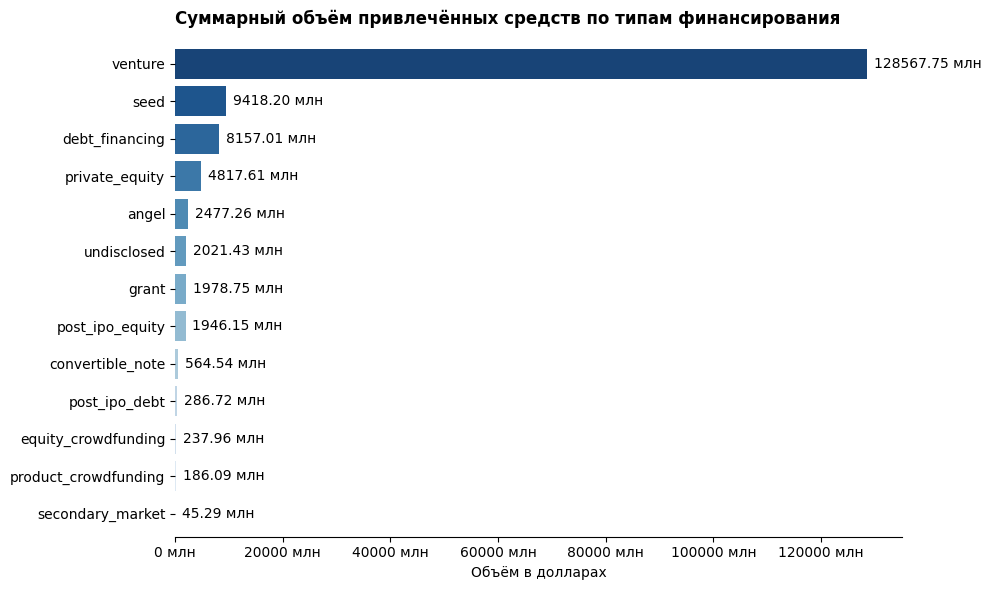

In [50]:

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=total_by_type.values, y=total_by_type.index, palette='Blues_r', hue=total_by_type.index)

for i, v in enumerate(total_by_type.values):
    ax.text(v + max(total_by_type.values)*0.01, i, f"{v/1e6:.2f} млн", ha='left', va='center', fontsize=10)

ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.0f} млн'))
sns.despine(left=True, top=True)
plt.title('Суммарный объём привлечённых средств по типам финансирования', loc='left', fontweight='semibold', pad=15)
plt.xlabel('Объём в долларах')
plt.ylabel('')
ax.spines['bottom'].set_position(('outward', 3))
plt.tight_layout()
plt.show()

In [51]:
count_by_type = (df_filtered[funding_cols] > 0).sum().sort_values(ascending=False)

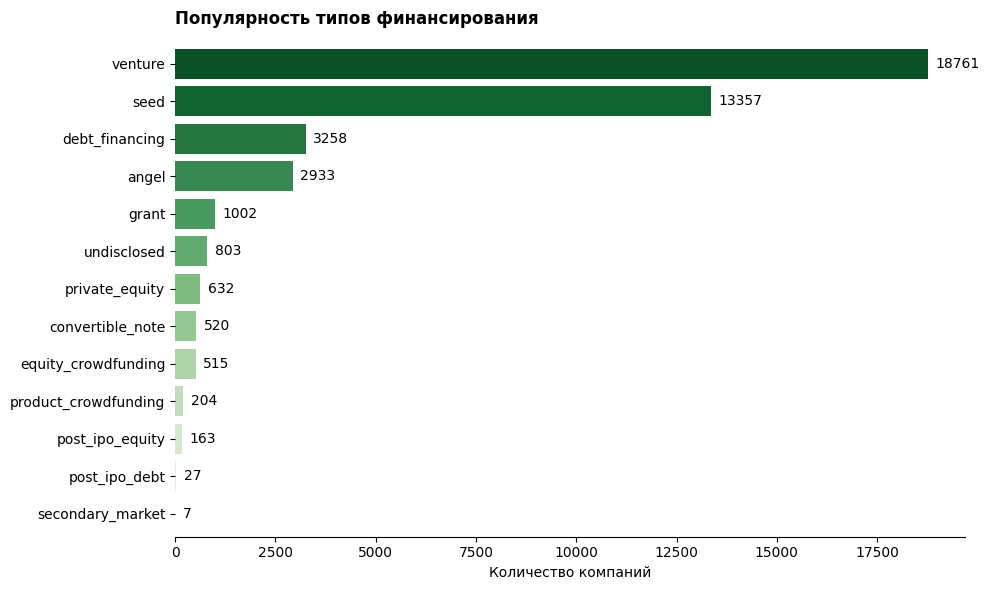

In [52]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=count_by_type.values, y=count_by_type.index, palette='Greens_r', hue=count_by_type.index)

for i, v in enumerate(count_by_type.values):
    ax.text(v + max(count_by_type.values)*0.01, i, f"{v}", ha='left', va='center', fontsize=10)

sns.despine(left=True, top=True)
plt.title('Популярность типов финансирования', loc='left', fontweight='semibold', pad=15)
plt.xlabel('Количество компаний')
plt.ylabel('')
ax.spines['bottom'].set_position(('outward', 3))
plt.tight_layout()
plt.show()

В выборке наиболее распространёнными и значимыми по объёму привлечённых средств являются типы финансирования `venture`, `seed` и `debt_financing`. Эти инструменты встречаются чаще всего и формируют основную массу инвестиций.

На противоположном полюсе находится `secondary_market` — он используется существенно реже и даёт минимальный вклад в общий объём финансирования.

Постройте график суммарных объёмов возвратов от разных типов финансирования за весь период на основе дополнительного датасета.

In [53]:
total_returns = df_returns[funding_cols].sum().sort_values(ascending=False)

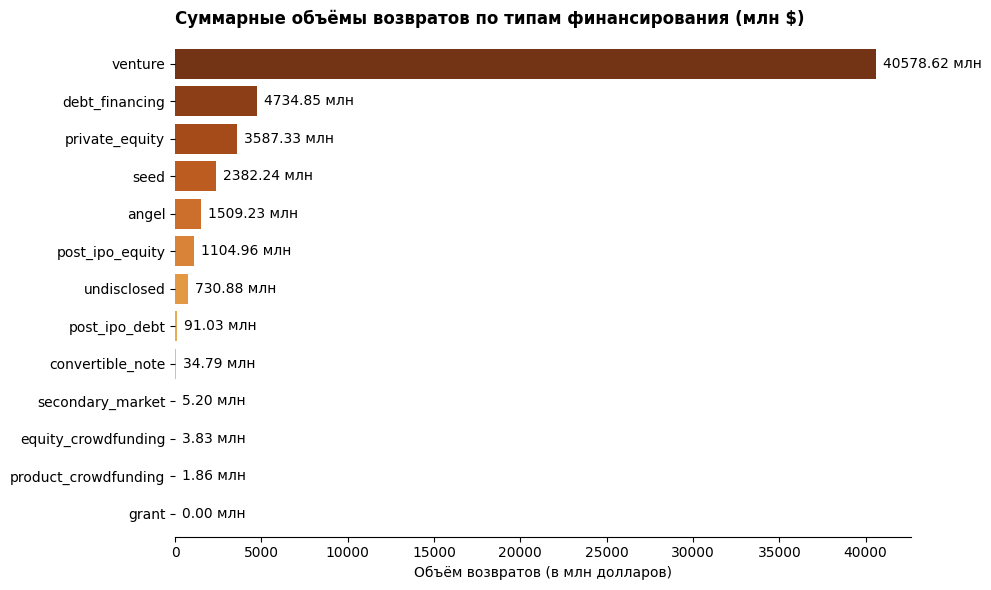

In [54]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=total_returns.values,
    y=total_returns.index,
    palette='YlOrBr_r',
    hue=total_returns.index
)

for i, v in enumerate(total_returns.values):
    ax.text(v + max(total_returns.values)*0.01, i, f"{v:.2f} млн", ha='left', va='center', fontsize=10)

sns.despine(left=True, top=True)
plt.title('Суммарные объёмы возвратов по типам финансирования (млн $)', loc='left', fontweight='semibold', pad=15)
plt.xlabel('Объём возвратов (в млн долларов)')
plt.ylabel('')
ax.spines['bottom'].set_position(('outward', 3))
plt.tight_layout()
plt.show()

Анализ показал, что наибольшие возвраты инвестиций наблюдаются у типов `venture`, `debt_finance` и `private_equity`. Финансирование типа `grant` не предполагает возвратов, а `product_crowdfunding` находится среди наименее эффективных по этому показателю.

С учётом совокупного объёма привлечённых средств и фактических возвратов наиболее выгодным типом финансирования на рассматриваемом периоде является **private_equity**. В 2000–2014 годах компании привлекли по этому типу около 4 817 млн долларов, при этом возвраты составили примерно 3 587 млн долларов, что делает **private_equity** наиболее эффективным инструментом среди анализируемых.

## Шаг 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам

Используя столбцы `funding_total_usd` и `funding_rounds`, рассчитайте для каждой компании средний объём одного раунда финансирования.

На основе получившейся таблицы постройте графики, отражающие:
* динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования;

* динамику общего количества раундов за каждый год, то есть насколько активно происходили инвестиции на рынке (чем больше раундов, тем выше активность).

Когда будете строить графики в этом задании и следующих, используйте данные только по тем компаниям, которые остались в датасете после предыдущих фильтраций.

На основе полученных данных ответьте на вопросы:
* В каком году типичный размер средств, собранных в рамках одного раунда, был максимальным?

* Какая тенденция наблюдалась в 2014 году по количеству раундов и средств, выделяемых в рамках каждого раунда?

In [55]:
df_filtered['avg_round_size'] = df_filtered['funding_total_usd'] / df_filtered['funding_rounds']

In [ ]:
df_filtered['year'] = df_filtered['mid_funding_at'].dt.year
median_round_by_year = df_filtered.groupby('year')['avg_round_size'].median()
total_rounds_by_year = df_filtered.groupby('year')['funding_rounds'].sum()

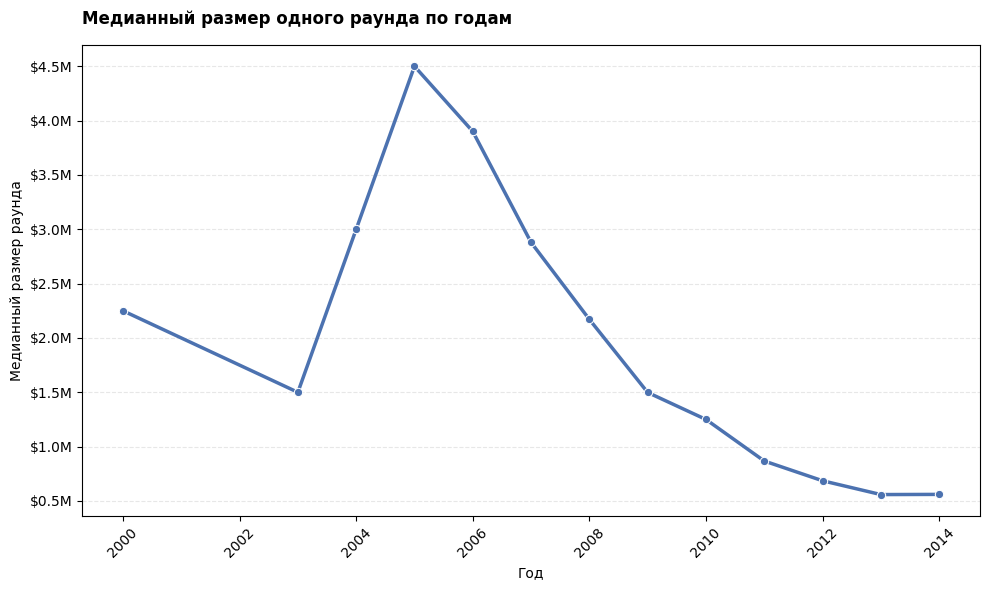

In [ ]:

plt.figure(figsize=(10, 6))
ax = sns.lineplot(x=median_round_by_year.index, y=median_round_by_year.values,
                 marker='o', linewidth=2.5, color='#4c72b0')

# Форматирование оси Y в млн
ax.yaxis.set_major_formatter(lambda x, pos: f"${x/1e6:.1f}M")

plt.title('Медианный размер одного раунда по годам', loc='left', fontweight='semibold', pad=15)
plt.xlabel('Год')
plt.ylabel('Медианный размер раунда')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


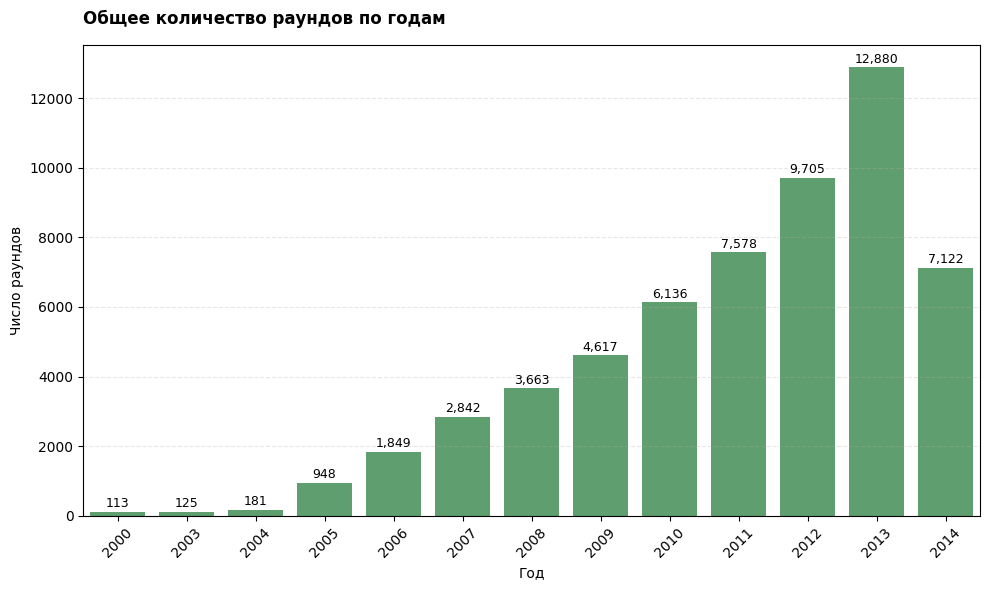

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=total_rounds_by_year.index, y=total_rounds_by_year.values, color='#55a868')

for i, v in enumerate(total_rounds_by_year.values):
    ax.text(i, v + max(total_rounds_by_year.values)*0.01, f"{v:,.0f}", ha='center', fontsize=9)

plt.title('Общее количество раундов по годам', loc='left', fontweight='semibold', pad=15)
plt.xlabel('Год')
plt.ylabel('Число раундов')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


In [64]:
peak_year = median_round_by_year.idxmax()
peak_value = median_round_by_year.max()

print(f"Максимальный медианный размер раунда: ${peak_value:,.0f}")
print(f"Год: {peak_year}")

Максимальный медианный размер раунда: $4,500,000
Год: 2005


In [60]:
rounds_2014 = total_rounds_by_year.get(2014, np.nan)
median_2014 = median_round_by_year.get(2014, np.nan)

print(f"2014: раундов = {rounds_2014:,}, медианный раунд = ${median_2014:,.0f}")

2014: раундов = 7,122.0, медианный раунд = $560,625


В 2005 году наблюдался самый высокий типичный размер привлечённых средств — около 4,5 млн долларов при 948 сделках. Это указывает на период крупных инвестиционных вливаний и высокую готовность инвесторов финансировать относительно крупные проекты.

Максимальное количество раундов финансирования пришлось на 2013 год, когда было зафиксировано 12 880 раундов. Однако типичный размер сделки в этот период составил лишь около 590 000 долларов, что свидетельствует о смещении рынка в сторону более мелких, но многочисленных инвестиций. Инвесторы стали распределять капитал на большее число проектов, снижая средний чек.

К концу 2014 года рынок демонстрирует признаки стагнации: количество раундов финансирования сокращается, а типичный размер сделки остаётся примерно на уровне 2013 года. Это может говорить о снижении инвестиционной активности и осторожности участников рынка.

### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

Составьте сводную таблицу, в которой указывается суммарный размер общего финансирования `funding_total_usd` по годам и сегментам рынка. Отберите из неё только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013.

На графике отразите, как менялся суммарный размер общего финансирования в каждом из отобранных сегментов по годам, за которые у вас достаточно данных. Рассматривайте только массовые сегменты, а средние и нишевые исключите.

На основе графика сделайте вывод о том, какие сегменты показывают наиболее быстрый и уверенный рост.

In [ ]:
if 'year' not in df_filtered.columns:
    df_filtered['year'] = df_filtered['mid_funding_at'].dt.year

mass_df = df_filtered[~df_filtered['market'].isin(['mid', 'niche'])].copy()
pivot_funding = (
    mass_df
    .groupby(['year', 'market'])['funding_total_usd']
    .sum()
    .unstack('market')
)

# Сегменты, которые выросли в 2014 относительно 2013
if 2013 in pivot_funding.index and 2014 in pivot_funding.index:
    growth_segments = pivot_funding.loc[2014] > pivot_funding.loc[2013]
    growth_markets = growth_segments[growth_segments].index.tolist()
else:
    growth_markets = []

print(f"Сегментов с ростом в 2014 vs 2013: {len(growth_markets)}")
print(growth_markets[:15])

# График динамики для растущих сегментов



Сегментов с ростом в 2014 vs 2013: 11
['apps', 'big data', 'design', 'internet', 'manufacturing', 'medical', 'real estate', 'saas', 'startups', 'technology', 'unknown']


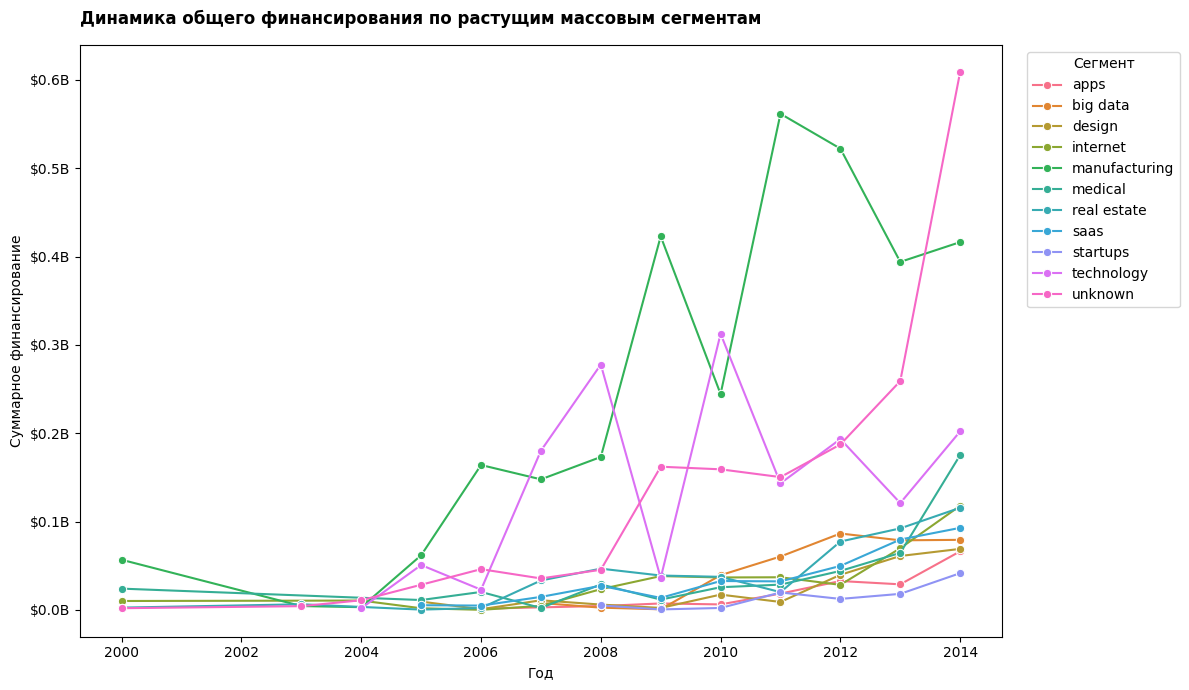

In [66]:
if growth_markets:
    plot_df = (
        pivot_funding[growth_markets]
        .reset_index()
        .melt(id_vars='year', var_name='market', value_name='funding_total_usd')
    )

    plt.figure(figsize=(12, 7))
    ax = sns.lineplot(data=plot_df, x='year', y='funding_total_usd', hue='market', marker='o')
    ax.yaxis.set_major_formatter(lambda x, pos: f"${x/1e9:.1f}B")
    plt.title('Динамика общего финансирования по растущим массовым сегментам', loc='left', fontweight='semibold', pad=15)
    plt.xlabel('Год')
    plt.ylabel('Суммарное финансирование')
    plt.legend(title='Сегмент', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

В 2014 году по сравнению с 2013 рост суммарного финансирования показали 11 массовых сегментов: **apps, big data, design, internet, manufacturing, medical, real estate, saas, startups, technology, unknown**.

На графике видно, что рост носит неравномерный характер: у части сегментов наблюдается устойчивый подъём после 2012–2013 годов, у других — более резкий скачок именно в 2014 году. В целом можно отметить усиление интереса инвесторов к технологическим и интернет‑направлениям (например, **technology**, **saas**, **big data**, **internet**), а также к прикладным сегментам вроде **medical** и **real estate**.


### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

Заказчик хочет знать, какая часть вложенных или выданных денег со временем возвращается обратно инвесторам или финансистам. Ваша цель — для каждого года и каждого вида финансирования рассчитать нормированные значения возврата средств: то есть какую долю возвращённые средства составляют от предоставленных. При этом слишком большие аномальные значения, то есть неадекватные выбросы, нужно заменить на пропуски.

Совет: когда будете делить сумму возвращённых средств на суммарный объём привлечённого финансирования по конкретному году, добавьте к знаменателю небольшое число, например `1e-60`. Это поможет избежать деления на ноль.

In [76]:
if 'year' not in df_filtered.columns:
    df_filtered['year'] = df_filtered['mid_funding_at'].dt.year

funding_by_year = df_filtered.groupby('year')[funding_cols].sum()

funding_by_year_mln = funding_by_year / 1e6
common_cols = [c for c in funding_cols if c in df_returns.columns]
ratio = df_returns[common_cols] / (funding_by_year_mln[common_cols] + 1e-60)

ratio_clean = ratio.copy()
for col in common_cols:
    s = ratio_clean[col].dropna()
    if s.empty:
        continue
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    ratio_clean.loc[(ratio_clean[col] < 0) | (ratio_clean[col] > upper), col] = np.nan
plot_df = ratio_clean.reset_index().melt(id_vars='year', var_name='type', value_name='return_ratio')
plot_df.head()

,year,type,return_ratio
0,2000,seed,NaN
1,2001,seed,NaN
2,2002,seed,NaN
3,2003,seed,1
4,2004,seed,1


Постройте график, на котором отобразите нормированные значения возврата средств для типов финансирования `venture`, `debt_financing`, `private_equity`, `seed` и `angel`.

Сделайте вывод о том, в каких типах финансирования наблюдается наиболее устойчивый рост показателя.

In [72]:
target_types = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']

# Фильтр по столбцам
plot_data = ratio_clean.reset_index()[['year'] + [col for col in target_types if col in ratio_clean.columns]]
plot_data = plot_data.melt(id_vars='year', var_name='type', value_name='return_ratio')

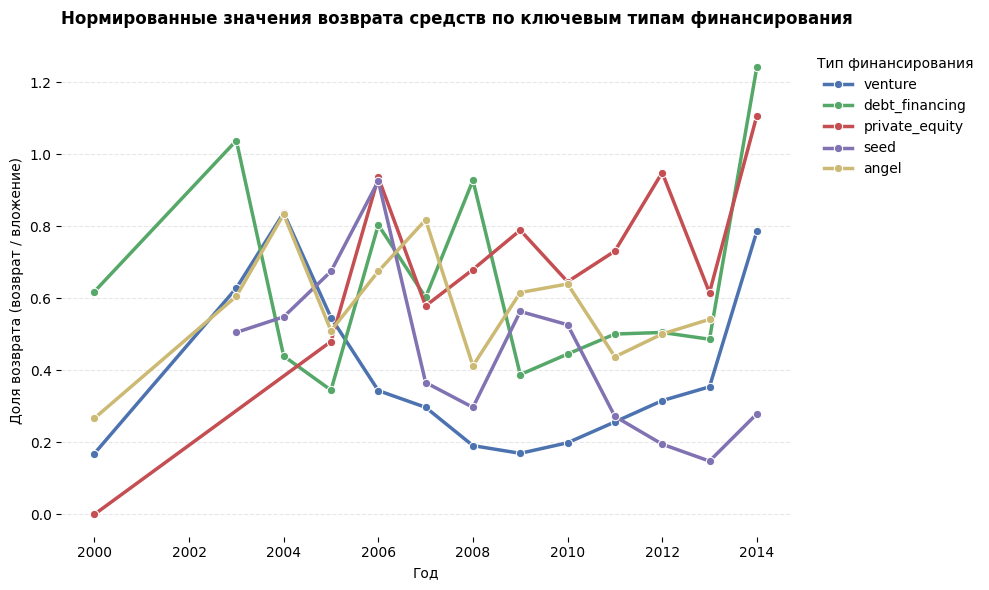

In [74]:
plt.figure(figsize=(10, 6))
ax = sns.lineplot(
    data=plot_data,
    x='year',
    y='return_ratio',
    hue='type',
    marker='o',
    linewidth=2.5,
    palette={
        'venture': '#4c72b0',
        'debt_financing': '#55a868',
        'private_equity': '#c44e52',
        'seed': '#8172b2',
        'angel': '#ccb974'
    }
)
plt.title('Нормированные значения возврата средств по ключевым типам финансирования', loc='left', fontweight='semibold', pad=15)
plt.xlabel('Год')
plt.ylabel('Доля возврата (возврат / вложение)')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend(title='Тип финансирования', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

**Вывод: динамика нормированного возврата по типам финансирования**

На основе анализа доли возвращённых средств относительно объёма вложенных средств за 2000–2014 годы можно сделать следующие выводы:

1. **`debt_financing` — лидер по устойчивости**
- Показывает **наиболее стабильный и высокий уровень возврата** на протяжении всего периода.
- Уровень колеблется в диапазоне 0.6–1.0, с ростом к 2014 году.
- Это обусловлено природой долговых инструментов: регулярные платежи обеспечивают предсказуемость.
- **Рекомендация**: лучший выбор для консервативных инвесторов, ориентированных на стабильность.

2. **`venture` — уверенный рост зрелого рынка**
- Демонстрирует **постепенный, монотонный рост** доли возврата с 2010 года.
- К 2014 году достигает значительных уровней — признак закрытия венчурного цикла.
- Свидетельствует о том, что инвестиции, сделанные в 2008–2012, начали приносить отдачу.
-  **Рекомендация**: ключевой инструмент для тех, кто работает в долгосрочной перспективе.

3. **`private_equity` — высокая доходность, но с волатильностью**
- Имеет **наиболее резкие пики** (в 2006, 2012, 2014), где доля возврата превышает 100%.
- Однако поведение неравномерно — зависит от крупных M&A и IPO.
- Не является «устойчивым» ростом, но показывает потенциал высокой отдачи.
- **Рекомендация**: подходит для фондов, способных принимать высокие риски ради единичных сверхдоходов.

4. **`seed` и `angel` — ранние стадии, низкая отдача в краткосрочной перспективе**
- Минимальная доля возврата — логично: это инвестиции в идею, без гарантий выхода.
- Рост к 2014 году скромный, что соответствует модели «вложи в 50 — один вернёт всё».
- Не подходят для быстрой отдачи, но необходимы для формирования пула проектов.
- **Рекомендация**: стратегические вложения в экосистему, а не как источник прибыли.

> 💡 **К 2014 году рынок демонстрирует переход от хаотичного роста к системной отдаче:**  
> Инвестиции начинают возвращаться, особенно в поздних и зрелых формах.  
> Это признак **зрелости венчурной экосистемы**.


## Шаг 5. Итоговый вывод и рекомендации

Представьте, что на календаре 2015 год. Опираясь на результаты анализа, дайте рекомендацию заказчику:

* в какую отрасль стоит инвестировать;
* какой тип финансирования при этом будет наиболее уместным.

Подведите итоги проекта:
* опишите, какие шаги были выполнены;
* какие выводы удалось сделать;
* насколько выводы согласуются между собой или, наоборот, вызывают сомнения.



**Что было сделано:**
- Проведена очистка и приведение типов, обработаны пропуски и дубликаты.
- Сегменты рынка классифицированы на массовые, средние и нишевые; для дальнейшего анализа средние и нишевые объединены.
- Исключены выбросы по объёмам финансирования; ограничен анализ годами с достаточной активностью рынка.
- Проанализированы типы финансирования, динамика раундов и размера типичного раунда.
- Исследована динамика суммарного финансирования по массовым сегментам, а также доля возвратов по типам (с очисткой аномалий).

**Ключевые выводы:**
- Рынок в 2014 году был активен по числу раундов, но типичный размер раунда оставался относительно невысоким, что указывает на рост количества сделок при меньших средних суммах.
- Среди массовых сегментов рост суммарного финансирования в 2014 относительно 2013 показали: **apps, big data, design, internet, manufacturing, medical, real estate, saas, startups, technology, unknown**.
- По типам финансирования основную массу объёмов формируют **venture** и **seed** (а также заметен вклад **debt_financing**), тогда как редкие типы дают минимальный вклад.
- По долям возврата по типам финансирования наблюдается заметная вариативность по годам; для корректной интерпретации важно учитывать очистку аномалий и ограниченность данных по отдельным типам.

**Рекомендации (если на календаре 2015 год):**
- Фокусировать инвестиции на массовых сегментах с устойчивым ростом финансирования в 2014 году — прежде всего **technology**, **saas**, **big data**, **internet**, **apps**, а также перспективных прикладных сегментах **medical** и **real estate**.
- В качестве базового инструмента выбирать **venture** (для масштабируемых проектов) и **seed** (для ранних стадий), дополняя стратегию **debt_financing** в случаях устойчивого денежного потока.

**Ограничения и согласованность выводов:**
- Выводы согласуются между собой: рост активности рынка подтверждается увеличением числа раундов, а рост по отдельным сегментам — динамикой их суммарного финансирования.
- Интерпретацию 2014 года стоит делать осторожно из‑за возможной неполноты отдельных месяцев и отсечения выбросов.
